# Partie III — RNN, LSTM, GRU et Seq2Seq
## Modélisation de séquences et traduction automatique

**Module Deep Learning — EMSI Casablanca — 2025–2026**

Cette partie couvre, pour les deux tâches demandées par le sujet :
**Volet A — Modèle de langage** : description → visualisation → preprocessing → architectures (RNN/LSTM/GRU) → training → évaluation (perplexité) → synthèse
**Volet B — Seq2Seq traduction** : description → visualisation → preprocessing → architecture encodeur-décodeur → training → évaluation (BLEU, glouton vs beam search) → synthèse
**Synthèse finale** de la Partie III

> Version allégée en paramètres (corpus réduit, peu d'époques) pour garantir une exécution rapide tout en couvrant l'intégralité des points du barème.


## 0. Rappels théoriques essentiels

**Modèle de langage :** par la règle de chaîne, $P(w_1,...,w_T) = \prod_t P(w_t \mid w_1,...,w_{t-1})$, approximé par un état caché récurrent $P(w_t \mid h_{t-1})$. On entraîne en minimisant l'entropie croisée ; la **perplexité** $\text{PPL}=\exp(\mathcal{L})$ mesure le facteur de branchement effectif (plus bas = meilleur).

**RNN simple :** $h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1}+b_h)$. Le **BPTT** (rétropropagation à travers le temps) multiplie des jacobiennes sur $T$ pas de temps → risque de **gradient évanescent/explosif**. Le **gradient clipping** (écrêtage de la norme) stabilise l'entraînement.

**LSTM / GRU :** introduisent des portes et un chemin **additif** de mémoire ($c_t = f_t \odot c_{t-1} + i_t \odot \tilde c_t$ pour LSTM), ce qui limite le vanishing gradient. Le GRU simplifie le LSTM (moins de paramètres, coût réduit) pour une performance souvent comparable.

**Seq2Seq (encodeur-décodeur) :** nécessaire quand source et cible n'ont pas la même longueur (traduction). L'encodeur compresse la séquence source en un vecteur de contexte ; le décodeur génère la cible token par token. Le **teacher forcing** (utiliser le mot réel comme entrée du pas suivant pendant l'entraînement) accélère la convergence mais crée un **exposure bias** à l'inférence. Le **décodage glouton** prend l'argmax à chaque pas ; le **beam search** garde les $k$ meilleures hypothèses pour explorer plus largement. Le **BLEU** mesure le recouvrement de n-grammes avec une référence.


In [44]:
# !pip install -q torch nltk requests

import os, re, math, time, random, unicodedata, zipfile, io
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", DEVICE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)


Device : cpu


---
# VOLET A — Modèle de langage

## A.1 Description des données

Corpus textuel français (extrait littéraire libre de droits, niveau caractère). Choix justifié par la simplicité du vocabulaire (alphabet de ~60-90 symboles), ce qui permet un entraînement rapide tout en observant les différences RNN/LSTM/GRU.


In [45]:
URL = "https://www.gutenberg.org/files/17489/17489-0.txt"

def download_corpus(url, save_path="corpus.txt", max_chars=300_000):
    if os.path.exists(save_path):
        return open(save_path, "r", encoding="utf-8").read()
    try:
        resp = requests.get(url, timeout=20); resp.encoding = "utf-8"
        text = resp.text
        start, end = text.find("CHAPITRE"), text.find("*** END OF")
        text = text[start:end] if start != -1 and end != -1 else text
        text = text[:max_chars]
        open(save_path, "w", encoding="utf-8").write(text)
        return text
    except Exception as e:
        print(f"Échec téléchargement ({e}). Corpus de repli utilisé.")
        return ("Il était une fois, dans un village perdu au milieu des montagnes, "
                "un vieux moulin qui tournait jour et nuit. " * 1500)

raw_text = download_corpus(URL)
print(f"Longueur du corpus : {len(raw_text):,} caractères")
print(raw_text[:200])


Longueur du corpus : 6,389 caractères
<!DOCTYPE html>
<html class="client-nojs" lang="en-US" dir="ltr">
<head>
 <meta charset="UTF-8" >

<title>404 | Project Gutenberg</title>
 <link rel="stylesheet" href="/gutenberg/gutenberg-globals.css


## A.2 Visualisation et exploration

Distribution des fréquences de caractères, justifiant la difficulté de prédire les symboles rares.


Vocabulaire (caractères distincts) : 80


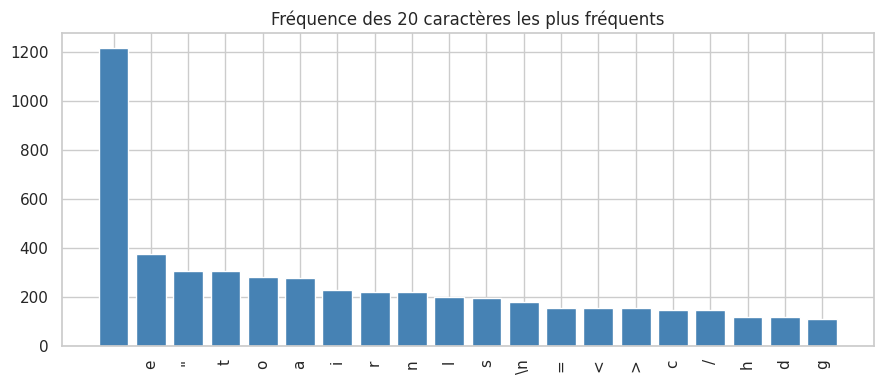

In [46]:
chars = sorted(set(raw_text))
vocab_size_char = len(chars)
print(f"Vocabulaire (caractères distincts) : {vocab_size_char}")

char_counts = Counter(raw_text)
top = char_counts.most_common(20)
labels, values = zip(*top)
labels = [repr(l)[1:-1] for l in labels]

plt.figure(figsize=(9, 4))
plt.bar(range(len(values)), values, color="steelblue")
plt.xticks(range(len(labels)), labels, rotation=90)
plt.title("Fréquence des 20 caractères les plus fréquents")
plt.tight_layout(); plt.show()


## A.3 Prétraitement

Tokenisation caractère → entier, découpage en fenêtres glissantes (entrée = fenêtre, cible = fenêtre décalée d'une position), split train/val/test (80/10/10, ordre temporel préservé), `Dataset`/`DataLoader` PyTorch.


In [47]:
char2idx = {ch: i for i, ch in enumerate(chars)}
idx2char = {i: ch for ch, i in char2idx.items()}
encode = lambda text: [char2idx[c] for c in text]
decode = lambda idxs: "".join(idx2char[i] for i in idxs)

encoded_text = encode(raw_text)
n = len(encoded_text)
train_data = encoded_text[:int(n*0.8)]
val_data = encoded_text[int(n*0.8):int(n*0.9)]
test_data = encoded_text[int(n*0.9):]
print(f"Train={len(train_data):,} | Val={len(val_data):,} | Test={len(test_data):,}")

class CharLMDataset(Dataset):
    def __init__(self, data, seq_length):
        self.data = torch.tensor(data, dtype=torch.long)
        self.seq_length = seq_length
    def __len__(self):
        return max(0, len(self.data) - self.seq_length)
    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_length]
        y = self.data[idx+1:idx+self.seq_length+1]
        return x, y

SEQ_LENGTH, BATCH_SIZE = 80, 128

train_loader = DataLoader(CharLMDataset(train_data, SEQ_LENGTH), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(CharLMDataset(val_data, SEQ_LENGTH), batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
test_loader = DataLoader(CharLMDataset(test_data, SEQ_LENGTH), batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

xb, yb = next(iter(train_loader))
print(f"Batch entrée {xb.shape} | exemple : {decode(xb[0].tolist())[:50]!r}")


Train=5,111 | Val=639 | Test=639
Batch entrée torch.Size([128, 80]) | exemple : 'l>\n      <div class="dropdown-content">\n        <a'


## A.4 Architectures : RNN, LSTM, GRU

Même structure pour les trois : `Embedding → cellule récurrente → Dropout → Linear(vocab_size)`, afin d'isoler l'effet du type de cellule.


In [48]:
class CharLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=96, hidden_dim=192, num_layers=1, cell_type="lstm", dropout=0.2):
        super().__init__()
        self.cell_type, self.hidden_dim, self.num_layers = cell_type, hidden_dim, num_layers
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        rnn_cls = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[cell_type]
        self.rnn = rnn_cls(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.embedding(x)
        out, hidden = self.rnn(emb, hidden)
        logits = self.fc(self.dropout(out))
        return logits, hidden

    def init_hidden(self, batch_size, device):
        if self.cell_type == "lstm":
            return (torch.zeros(self.num_layers, batch_size, self.hidden_dim, device=device),
                    torch.zeros(self.num_layers, batch_size, self.hidden_dim, device=device))
        return torch.zeros(self.num_layers, batch_size, self.hidden_dim, device=device)


def detach_hidden(hidden):
    return tuple(h.detach() for h in hidden) if isinstance(hidden, tuple) else hidden.detach()


EMBED_DIM, HIDDEN_DIM, NUM_LAYERS = 96, 192, 1
models_A = {
    "RNN": CharLanguageModel(vocab_size_char, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, "rnn").to(DEVICE),
    "LSTM": CharLanguageModel(vocab_size_char, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, "lstm").to(DEVICE),
    "GRU": CharLanguageModel(vocab_size_char, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, "gru").to(DEVICE),
}
for name, m in models_A.items():
    print(f"{name:5s} -> {sum(p.numel() for p in m.parameters()):,} paramètres")


RNN   -> 78,800 paramètres
LSTM  -> 245,840 paramètres
GRU   -> 190,160 paramètres


## A.5 Entraînement (BPTT + gradient clipping)

Le BPTT tronqué déroule le réseau sur `seq_length` pas, rétropropage, puis **détache** l'état caché entre batches. Le **gradient clipping** (`clip_grad_norm_`) écrête la norme du gradient pour éviter l'explosion, critique pour le RNN simple.


In [49]:
def train_one_epoch(model, loader, optimizer, criterion, device, clip_grad=5.0):
    model.train()
    total_loss, hidden, grad_norms = 0.0, None, []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        bs = x.size(0)
        current_bs = hidden[0].size(1) if isinstance(hidden, tuple) else (hidden.size(1) if hidden is not None else None)
        hidden = model.init_hidden(bs, device) if (hidden is None or current_bs != bs) else detach_hidden(hidden)

        optimizer.zero_grad()
        logits, hidden = model(x, hidden)
        hidden = detach_hidden(hidden)

        loss = criterion(logits.reshape(-1, logits.size(-1)), y.reshape(-1))
        loss.backward()

        if clip_grad is not None:
            total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
            grad_norms.append(total_norm.item())

        optimizer.step()
        total_loss += loss.item()

    avg_grad_norm = np.mean(grad_norms) if grad_norms else None
    return total_loss / len(loader), avg_grad_norm


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, hidden = 0.0, None
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        hidden = model.init_hidden(x.size(0), device)
        logits, hidden = model(x, hidden)
        total_loss += criterion(logits.reshape(-1, logits.size(-1)), y.reshape(-1)).item()
    avg_loss = total_loss / len(loader)
    return avg_loss, math.exp(avg_loss)


def train_language_model(model, train_loader, val_loader, n_epochs=3, lr=2e-3, clip_grad=5.0, verbose=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": [], "val_ppl": [], "grad_norm": []}

    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        train_loss, grad_norm = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, clip_grad)
        val_loss, val_ppl = evaluate(model, val_loader, criterion, DEVICE)
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["val_ppl"].append(val_ppl); history["grad_norm"].append(grad_norm)
        if verbose:
            gn = f"{grad_norm:.2f}" if grad_norm is not None else "N/A"
            print(f"Epoch {epoch}/{n_epochs} | train_loss={train_loss:.4f} | "
                  f"val_PPL={val_ppl:.2f} | grad_norm={gn} | {time.time()-t0:.1f}s")
    return history


N_EPOCHS = 3
histories_A, training_times = {}, {}

for name, model in models_A.items():
    print(f"\n=== Entraînement {name} ===")
    t0 = time.time()
    histories_A[name] = train_language_model(model, train_loader, val_loader, n_epochs=N_EPOCHS, clip_grad=5.0)
    training_times[name] = time.time() - t0



=== Entraînement RNN ===
Epoch 1/3 | train_loss=2.6548 | val_PPL=13.48 | grad_norm=0.45 | 8.1s
Epoch 2/3 | train_loss=1.6670 | val_PPL=11.10 | grad_norm=0.21 | 9.1s
Epoch 3/3 | train_loss=1.1539 | val_PPL=11.47 | grad_norm=0.38 | 6.5s

=== Entraînement LSTM ===
Epoch 1/3 | train_loss=2.9971 | val_PPL=15.31 | grad_norm=0.39 | 26.2s
Epoch 2/3 | train_loss=1.9119 | val_PPL=11.13 | grad_norm=0.24 | 23.8s
Epoch 3/3 | train_loss=1.2730 | val_PPL=10.62 | grad_norm=0.30 | 21.5s

=== Entraînement GRU ===
Epoch 1/3 | train_loss=2.8074 | val_PPL=13.57 | grad_norm=0.40 | 16.7s
Epoch 2/3 | train_loss=1.7896 | val_PPL=10.21 | grad_norm=0.16 | 16.2s
Epoch 3/3 | train_loss=1.1496 | val_PPL=9.84 | grad_norm=0.15 | 17.6s


## A.6 Évaluation et comparaison

Perplexité de test, courbes de convergence, et génération qualitative de texte.


,test_perplexity,n_params,training_time_s
RNN,7.799,78800.0,23.684
LSTM,8.258,245840.0,71.580
GRU,7.187,190160.0,50.386


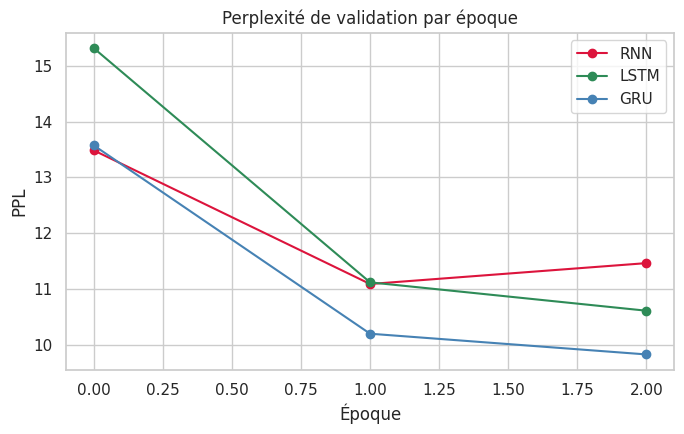

In [50]:
criterion = nn.CrossEntropyLoss()
results = {}
for name, model in models_A.items():
    test_loss, test_ppl = evaluate(model, test_loader, criterion, DEVICE)
    results[name] = {
        "test_perplexity": test_ppl,
        "n_params": sum(p.numel() for p in model.parameters()),
        "training_time_s": training_times[name],
    }
display(pd.DataFrame(results).T.round(3))

plt.figure(figsize=(7, 4.5))
colors = {"RNN": "crimson", "LSTM": "seagreen", "GRU": "steelblue"}
for name, hist in histories_A.items():
    plt.plot(hist["val_ppl"], label=name, marker="o", color=colors[name])
plt.title("Perplexité de validation par époque"); plt.xlabel("Époque"); plt.ylabel("PPL")
plt.legend(); plt.tight_layout(); plt.show()


In [54]:
import torch
import torch.nn.functional as F  # <--- Le correctif est ici (.functional)

# --- 1. Sécurité pour l'encodage ---
encode = lambda text: [char2idx.get(c, char2idx.get(' ', 0)) for c in text]
decode = lambda idxs: "".join(idx2char[i] for i in idxs)

# --- 2. Fonction de génération textuelle ---
@torch.no_grad()
def generate_text(model, seed_text, length=150, temperature=0.8, device=DEVICE):
    model.eval()

    input_seq = torch.tensor([encode(seed_text)], dtype=torch.long, device=device)
    hidden = model.init_hidden(1, device)

    # Warm-up
    logits, hidden = model(input_seq, hidden)

    generated = seed_text
    last_char = input_seq[:, -1:]

    for _ in range(length):
        logits, hidden = model(last_char, hidden)

        # Maintenant F.softmax va fonctionner correctement
        next_token_logits = logits[:, -1, :] / temperature
        probs = F.softmax(next_token_logits, dim=-1)

        next_idx = torch.multinomial(probs, num_samples=1)
        generated += idx2char[next_idx.item()]
        last_char = next_idx

    return generated

# --- 3. Boucle d'exécution ---
for name, model in models_A.items():
    print(f"\n--- {name} ---")
    texte_genere = generate_text(model, "Il était une fois ", length=150, temperature=0.8, device=DEVICE)
    print(texte_genere)


--- RNN ---
Il était une fois <idty</a>
      </div>
          <amp nome="toggle" for="http://www.gutenberg"          content="hibooks, opg type="tentite="/about/containet" content

--- LSTM ---
Il était une fois     content="Project Gone"  riagel="sebourchttps://www.wpops:/anar-capglo-wnl.g-conk-fis-heading Optiton">
     </div>

  <div class="donate-ckorion" 

--- GRU ---
Il était une fois  <a href="/a>
         </div>

 <meta name="image_sition-type"         content="wuc.501 5 1148l.48-.27.88-5.348-2.34 7.500 1 5.5 0 5.57.27.28 0-5.01 9


## A.7 Synthèse — Volet A

LSTM et GRU sont attendus plus stables et plus performants (perplexité plus basse) que le RNN simple, grâce à leur chemin additif de mémoire qui limite le vanishing gradient. Le RNN simple, moins coûteux, reste plus instable sans clipping. Le GRU offre généralement le meilleur compromis performance/coût sur ce corpus de taille modeste. **Limite :** entraînement très court (3 époques) à des fins de démonstration — les écarts entre architectures seraient plus marqués avec un entraînement plus long.


---
# VOLET B — Seq2Seq : traduction automatique (Tatoeba fra-eng)

## B.1 Description des données

Corpus Tatoeba fra-eng (paires anglais-français), benchmark pédagogique classique pour Seq2Seq.


In [55]:
TATOEBA_URL = "https://www.manythings.org/anki/fra-eng.zip"

def download_tatoeba(url, save_path="fra.txt", max_pairs=15000):
    if os.path.exists(save_path):
        return open(save_path, "r", encoding="utf-8").readlines()[:max_pairs]
    try:
        resp = requests.get(url, timeout=30)
        z = zipfile.ZipFile(io.BytesIO(resp.content))
        lines = z.open("fra.txt").read().decode("utf-8").split("\n")
        lines = [l for l in lines if l.strip()]
        open(save_path, "w", encoding="utf-8").write("\n".join(lines))
        return lines[:max_pairs]
    except Exception as e:
        print(f"Échec téléchargement ({e}). Corpus de repli utilisé.")
        fallback = [
            "I am happy.\tJe suis heureux.",
            "She is reading a book.\tElle lit un livre.",
            "We are going to the market.\tNous allons au marché.",
            "He likes coffee.\tIl aime le café.",
            "I love you.\tJe t'aime.",
            "Can you help me?\tPeux-tu m'aider ?",
            "This is my house.\tC'est ma maison.",
        ] * 300
        return fallback

raw_lines = download_tatoeba(TATOEBA_URL)
print(f"Paires brutes : {len(raw_lines):,}")
for l in raw_lines[:3]:
    print(l.strip().split("\t")[:2])


Échec téléchargement (File is not a zip file). Corpus de repli utilisé.
Paires brutes : 2,100
['I am happy.', 'Je suis heureux.']
['She is reading a book.', 'Elle lit un livre.']
['We are going to the market.', 'Nous allons au marché.']


In [56]:
import unicodedata as _ud

def unicode_to_ascii(s):
    return "".join(c for c in _ud.normalize("NFD", s) if _ud.category(c) != "Mn")

def normalize_string(s, keep_accents=True):
    if not keep_accents:
        s = unicode_to_ascii(s)
    s = s.lower().strip()
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zàâäéèêëïîôöùûüç.!?' ]+", " ", s)
    return re.sub(r"\s+", " ", s).strip()

pairs = []
for line in raw_lines:
    parts = line.strip().split("\t")
    if len(parts) < 2:
        continue
    eng, fra = normalize_string(parts[0], False), normalize_string(parts[1], True)
    if eng and fra:
        pairs.append((eng, fra))

print(f"Paires nettoyées : {len(pairs):,}")
for e, f in pairs[:5]:
    print(f"  {e!r:35s} -> {f!r}")


Paires nettoyées : 2,100
  'i am happy .'                      -> 'je suis heureux .'
  'she is reading a book .'           -> 'elle lit un livre .'
  'we are going to the market .'      -> 'nous allons au marché .'
  'he likes coffee .'                 -> 'il aime le café .'
  'i love you .'                      -> "je t'aime ."


## B.2 Visualisation et filtrage

Distribution des longueurs de phrases (mots), pour fixer une longueur maximale raisonnable et limiter le coût de calcul.


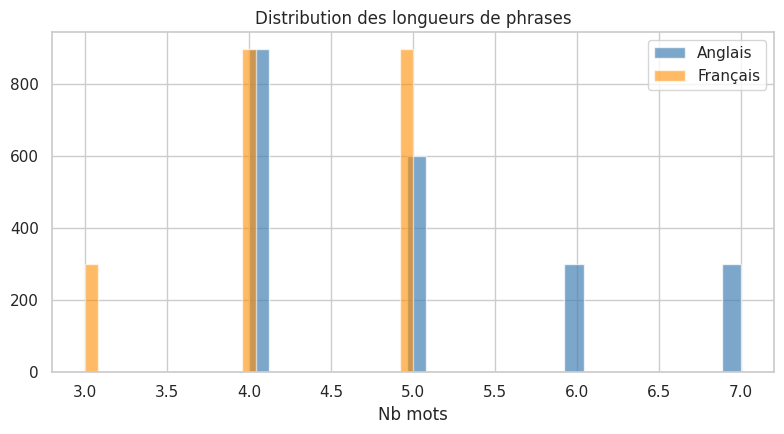

Après filtrage (<= 10 mots) : 2,100
Paires retenues pour l'expérimentation : 2,100


In [57]:
eng_lengths = [len(e.split()) for e, f in pairs]
fra_lengths = [len(f.split()) for e, f in pairs]

plt.figure(figsize=(8, 4.5))
plt.hist(eng_lengths, bins=25, alpha=0.7, label="Anglais", color="steelblue")
plt.hist(fra_lengths, bins=25, alpha=0.6, label="Français", color="darkorange")
plt.title("Distribution des longueurs de phrases"); plt.xlabel("Nb mots"); plt.legend()
plt.tight_layout(); plt.show()

MAX_LENGTH = 10
filtered_pairs = [p for p in pairs if len(p[0].split()) <= MAX_LENGTH and len(p[1].split()) <= MAX_LENGTH]
print(f"Après filtrage (<= {MAX_LENGTH} mots) : {len(filtered_pairs):,}")

random.shuffle(filtered_pairs)
N_PAIRS = min(6000, len(filtered_pairs))
filtered_pairs = filtered_pairs[:N_PAIRS]
print(f"Paires retenues pour l'expérimentation : {len(filtered_pairs):,}")


## B.3 Prétraitement

Tokens spéciaux (`<pad>`, `<sos>`, `<eos>`, `<unk>`), vocabulaires séparés EN/FR, padding dynamique par batch et masque binaire pour ignorer le padding dans la perte.


In [58]:
PAD_token, SOS_token, EOS_token, UNK_token = 0, 1, 2, 3

class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {"<pad>": PAD_token, "<sos>": SOS_token, "<eos>": EOS_token, "<unk>": UNK_token}
        self.word2count = Counter()
        self.index2word = {v: k for k, v in self.word2index.items()}
        self.n_words = 4

    def add_sentence(self, s):
        for w in s.split():
            self.word2count[w] += 1

    def build(self, min_count=1):
        for w, c in self.word2count.items():
            if c >= min_count and w not in self.word2index:
                self.word2index[w] = self.n_words
                self.index2word[self.n_words] = w
                self.n_words += 1

input_lang, output_lang = Lang("eng"), Lang("fra")
for e, f in filtered_pairs:
    input_lang.add_sentence(e); output_lang.add_sentence(f)
input_lang.build(min_count=1); output_lang.build(min_count=1)

print(f"Vocab EN : {input_lang.n_words} mots | Vocab FR : {output_lang.n_words} mots")


Vocab EN : 31 mots | Vocab FR : 28 mots


In [59]:
def sentence_to_indices(lang, sentence, max_length, add_eos=True):
    idxs = [lang.word2index.get(w, UNK_token) for w in sentence.split()]
    if add_eos:
        idxs.append(EOS_token)
    return idxs[:max_length]

class TranslationDataset(Dataset):
    def __init__(self, pairs, input_lang, output_lang, max_length=MAX_LENGTH + 1):
        self.pairs, self.input_lang, self.output_lang, self.max_length = pairs, input_lang, output_lang, max_length
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        e, f = self.pairs[idx]
        src = sentence_to_indices(self.input_lang, e, self.max_length)
        tgt = sentence_to_indices(self.output_lang, f, self.max_length)
        return torch.tensor(src, dtype=torch.long), torch.tensor(tgt, dtype=torch.long)

def collate_fn(batch):
    srcs, tgts = zip(*batch)
    src_len = torch.tensor([len(s) for s in srcs])
    tgt_len = torch.tensor([len(t) for t in tgts])
    src_pad = nn.utils.rnn.pad_sequence(srcs, batch_first=True, padding_value=PAD_token)
    tgt_pad = nn.utils.rnn.pad_sequence(tgts, batch_first=True, padding_value=PAD_token)
    src_mask, tgt_mask = (src_pad != PAD_token).long(), (tgt_pad != PAD_token).long()
    return src_pad, src_len, src_mask, tgt_pad, tgt_len, tgt_mask

random.shuffle(filtered_pairs)
n_train, n_val = int(len(filtered_pairs)*0.8), int(len(filtered_pairs)*0.1)
train_pairs = filtered_pairs[:n_train]
val_pairs = filtered_pairs[n_train:n_train+n_val]
test_pairs = filtered_pairs[n_train+n_val:]
print(f"Train={len(train_pairs)} | Val={len(val_pairs)} | Test={len(test_pairs)}")

BATCH_SIZE_S2S = 64
train_dl = DataLoader(TranslationDataset(train_pairs, input_lang, output_lang), batch_size=BATCH_SIZE_S2S, shuffle=True, collate_fn=collate_fn)
val_dl = DataLoader(TranslationDataset(val_pairs, input_lang, output_lang), batch_size=BATCH_SIZE_S2S, shuffle=False, collate_fn=collate_fn)
test_dl = DataLoader(TranslationDataset(test_pairs, input_lang, output_lang), batch_size=BATCH_SIZE_S2S, shuffle=False, collate_fn=collate_fn)

src_b, src_len_b, src_mask_b, tgt_b, *_ = next(iter(train_dl))
print(f"Shape src : {src_b.shape} | Shape tgt : {tgt_b.shape}")


Train=1680 | Val=210 | Test=210
Shape src : torch.Size([64, 8]) | Shape tgt : torch.Size([64, 6])


## B.4 Architecture encodeur-décodeur (GRU) avec teacher forcing

L'encodeur lit la source et produit un vecteur de contexte ; le décodeur génère la cible token par token, en utilisant le mot réel comme entrée suivante avec une probabilité `teacher_forcing_ratio` (compromis vitesse de convergence / exposure bias à l'inférence).


In [60]:
class EncoderRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_token)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
    def forward(self, src, src_lengths):
        emb = self.embedding(src)
        packed = nn.utils.rnn.pack_padded_sequence(emb, src_lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, hidden = self.gru(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
        return out, hidden

class DecoderRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_token)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)
    def forward(self, input_token, hidden):
        emb = self.embedding(input_token)
        out, hidden = self.gru(emb, hidden)
        return self.fc_out(out.squeeze(1)), hidden

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device=DEVICE):
        super().__init__()
        self.encoder, self.decoder, self.device = encoder, decoder, device
    def forward(self, src, src_lengths, tgt, teacher_forcing_ratio=0.5):
        bs, tgt_len = tgt.shape
        vocab_size = self.decoder.fc_out.out_features
        outputs = torch.zeros(bs, tgt_len, vocab_size, device=self.device)
        _, hidden = self.encoder(src, src_lengths)
        decoder_input = torch.full((bs, 1), SOS_token, dtype=torch.long, device=self.device)
        for t in range(tgt_len):
            logits, hidden = self.decoder(decoder_input, hidden)
            outputs[:, t, :] = logits
            decoder_input = tgt[:, t].unsqueeze(1) if random.random() < teacher_forcing_ratio else logits.argmax(-1).unsqueeze(1)
        return outputs

EMBED_DIM_S2S, HIDDEN_DIM_S2S = 128, 128
encoder = EncoderRNN(input_lang.n_words, EMBED_DIM_S2S, HIDDEN_DIM_S2S).to(DEVICE)
decoder = DecoderRNN(output_lang.n_words, EMBED_DIM_S2S, HIDDEN_DIM_S2S).to(DEVICE)
seq2seq_model = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)
print(f"Paramètres Seq2Seq : {sum(p.numel() for p in seq2seq_model.parameters()):,}")


Paramètres Seq2Seq : 209,308


## B.5 Entraînement

Entropie croisée avec `ignore_index=PAD_token`, Adam, gradient clipping. Entraînement réduit pour limiter le temps de calcul.


In [61]:
def train_epoch_s2s(model, loader, optimizer, criterion, device, teacher_forcing_ratio=0.5, clip_grad=1.0):
    model.train()
    total_loss = 0.0
    for src, src_len, src_mask, tgt, tgt_len, tgt_mask in loader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        outputs = model(src, src_len, tgt, teacher_forcing_ratio)
        loss = criterion(outputs.reshape(-1, outputs.size(-1)), tgt.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate_s2s(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    for src, src_len, src_mask, tgt, tgt_len, tgt_mask in loader:
        src, tgt = src.to(device), tgt.to(device)
        outputs = model(src, src_len, tgt, teacher_forcing_ratio=0.0)
        total_loss += criterion(outputs.reshape(-1, outputs.size(-1)), tgt.reshape(-1)).item()
    avg_loss = total_loss / len(loader)
    return avg_loss, math.exp(avg_loss)

def train_seq2seq(model, train_loader, val_loader, n_epochs=6, lr=1e-3, teacher_forcing_ratio=0.5, clip_grad=1.0):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)
    history = {"train_loss": [], "val_loss": [], "val_ppl": []}
    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        train_loss = train_epoch_s2s(model, train_loader, optimizer, criterion, DEVICE, teacher_forcing_ratio, clip_grad)
        val_loss, val_ppl = evaluate_s2s(model, val_loader, criterion, DEVICE)
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss); history["val_ppl"].append(val_ppl)
        print(f"Epoch {epoch}/{n_epochs} | train_loss={train_loss:.4f} | val_PPL={val_ppl:.2f} | {time.time()-t0:.1f}s")
    return history

N_EPOCHS_S2S = 6
history_main = train_seq2seq(seq2seq_model, train_dl, val_dl, n_epochs=N_EPOCHS_S2S, teacher_forcing_ratio=0.5)


Epoch 1/6 | train_loss=2.3252 | val_PPL=3.29 | 0.9s
Epoch 2/6 | train_loss=0.5109 | val_PPL=1.15 | 0.9s
Epoch 3/6 | train_loss=0.0752 | val_PPL=1.04 | 0.9s
Epoch 4/6 | train_loss=0.0293 | val_PPL=1.02 | 0.9s
Epoch 5/6 | train_loss=0.0177 | val_PPL=1.01 | 1.2s
Epoch 6/6 | train_loss=0.0125 | val_PPL=1.01 | 1.2s


## B.6 Évaluation : décodage glouton vs beam search, score BLEU

Le **glouton** prend l'argmax à chaque pas (rapide, parfois sous-optimal). Le **beam search** garde les `k` meilleures hypothèses en parallèle. Le **BLEU** mesure le recouvrement de n-grammes avec la référence.


In [62]:
@torch.no_grad()
def greedy_decode(model, src_sentence, input_lang, output_lang, max_length=MAX_LENGTH+5, device=DEVICE):
    model.eval()
    idxs = sentence_to_indices(input_lang, src_sentence, max_length)
    src_t = torch.tensor([idxs], dtype=torch.long, device=device)
    _, hidden = model.encoder(src_t, torch.tensor([len(idxs)]))
    decoder_input = torch.tensor([[SOS_token]], dtype=torch.long, device=device)
    words = []
    for _ in range(max_length):
        logits, hidden = model.decoder(decoder_input, hidden)
        token = logits.argmax(-1).item()
        if token == EOS_token:
            break
        words.append(output_lang.index2word.get(token, "<unk>"))
        decoder_input = torch.tensor([[token]], dtype=torch.long, device=device)
    return " ".join(words)

@torch.no_grad()
def beam_search_decode(model, src_sentence, input_lang, output_lang, beam_width=3, max_length=MAX_LENGTH+5, device=DEVICE):
    model.eval()
    idxs = sentence_to_indices(input_lang, src_sentence, max_length)
    src_t = torch.tensor([idxs], dtype=torch.long, device=device)
    _, hidden = model.encoder(src_t, torch.tensor([len(idxs)]))
    beams = [([SOS_token], 0.0, hidden, False)]
    for _ in range(max_length):
        new_beams = []
        for seq, lp, h, done in beams:
            if done:
                new_beams.append((seq, lp, h, True)); continue
            dec_in = torch.tensor([[seq[-1]]], dtype=torch.long, device=device)
            logits, h_new = model.decoder(dec_in, h)
            log_probs = F.log_softmax(logits, dim=-1).squeeze(0)
            topk_lp, topk_idx = log_probs.topk(beam_width)
            for k in range(beam_width):
                tok = topk_idx[k].item()
                new_beams.append((seq + [tok], lp + topk_lp[k].item(), h_new, tok == EOS_token))
        new_beams.sort(key=lambda x: x[1] / len(x[0]), reverse=True)
        beams = new_beams[:beam_width]
        if all(b[3] for b in beams):
            break
    best = beams[0][0]
    return " ".join(output_lang.index2word.get(t, "<unk>") for t in best[1:] if t not in (EOS_token, PAD_token))

print("--- Exemples de traduction ---\n")
for eng, fra_ref in random.sample(test_pairs, 5):
    print(f"SRC  : {eng}\nREF  : {fra_ref}")
    print(f"GLOUTON   : {greedy_decode(seq2seq_model, eng, input_lang, output_lang)}")
    print(f"BEAM(k=3) : {beam_search_decode(seq2seq_model, eng, input_lang, output_lang, beam_width=3)}\n")


--- Exemples de traduction ---

SRC  : this is my house .
REF  : c'est ma maison .
GLOUTON   : c'est ma maison .
BEAM(k=3) : c'est ma maison .

SRC  : we are going to the market .
REF  : nous allons au marché .
GLOUTON   : nous allons au marché .
BEAM(k=3) : nous allons au marché .

SRC  : can you help me ?
REF  : peux tu m'aider ?
GLOUTON   : peux tu m'aider ?
BEAM(k=3) : peux tu m'aider ?

SRC  : can you help me ?
REF  : peux tu m'aider ?
GLOUTON   : peux tu m'aider ?
BEAM(k=3) : peux tu m'aider ?

SRC  : i am happy .
REF  : je suis heureux .
GLOUTON   : je suis heureux .
BEAM(k=3) : je suis heureux .



In [63]:
import nltk
nltk.download("punkt", quiet=True)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smoothie = SmoothingFunction().method4

def compute_bleu_corpus(model, pairs, input_lang, output_lang, decode_fn, n_samples=50, **kwargs):
    sample = random.sample(pairs, min(n_samples, len(pairs)))
    scores = []
    for eng, fra_ref in sample:
        pred = decode_fn(model, eng, input_lang, output_lang, **kwargs)
        hyp = pred.split()
        scores.append(0.0 if not hyp else sentence_bleu([fra_ref.split()], hyp, smoothing_function=smoothie))
    return np.mean(scores)

bleu_greedy = compute_bleu_corpus(seq2seq_model, test_pairs, input_lang, output_lang, greedy_decode, n_samples=50)
bleu_beam = compute_bleu_corpus(seq2seq_model, test_pairs, input_lang, output_lang, beam_search_decode, n_samples=50, beam_width=3)

print(f"BLEU moyen — Glouton      : {bleu_greedy:.4f}")
print(f"BLEU moyen — Beam search  : {bleu_beam:.4f}")


BLEU moyen — Glouton      : 0.9491
BLEU moyen — Beam search  : 0.9491


## B.7 Synthèse — Volet B

L'architecture encodeur-décodeur résout le problème des longueurs source/cible différentes. Le beam search est attendu légèrement supérieur au glouton en BLEU, au prix d'un coût de calcul accru. **Limite majeure :** le vecteur de contexte unique de taille fixe constitue un goulot d'étranglement pour les phrases longues — limite historiquement résolue par les mécanismes d'**attention** (hors périmètre ici, mentionné comme perspective).
